In [474]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("laptop_price.csv", encoding="latin-1")
print(df.shape) #Check data shape
print(df.columns.tolist()) #Check column names
print(df.head(3)) #Check the first 3 rows

(1303, 13)
['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros']
   laptop_ID Company      Product  ...  OpSys  Weight Price_euros
0          1   Apple  MacBook Pro  ...  macOS  1.37kg     1339.69
1          2   Apple  Macbook Air  ...  macOS  1.34kg      898.94
2          3      HP       250 G6  ...  No OS  1.86kg      575.00

[3 rows x 13 columns]


In [475]:
print(df.info()) #Check data info
print("\n")
print(df.describe()) #Check data statistics

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 132.5 KB
None


         laptop_ID       Inches  Price_euros
count  1303.000000  1303.000000  1303.000000
mean    660.155794    15.017191  1123.686

In [476]:
print(df.isnull().sum()) #Check for missing values

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64


In [477]:
print(df["Company"].value_counts()) #Check for unique values in "Company" column, and number of times it appears

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64


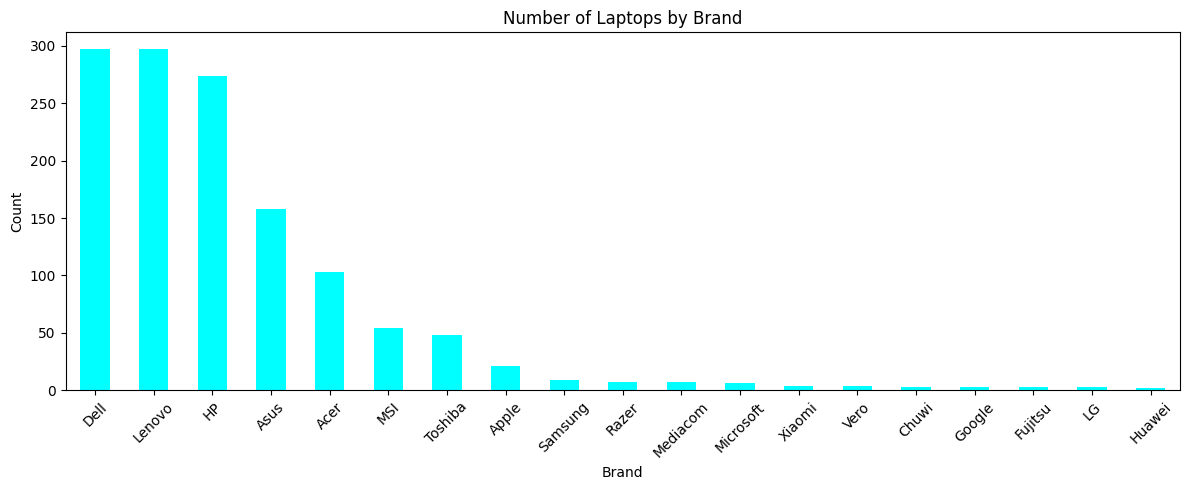

In [478]:
plt.figure(figsize=(12,5))
df["Company"].value_counts().plot(kind="bar", color="cyan")
plt.title("Number of Laptops by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45) #Rotate x-axis label for better readability
plt.tight_layout() #Adjust layout to prevent overlap
plt.show() 

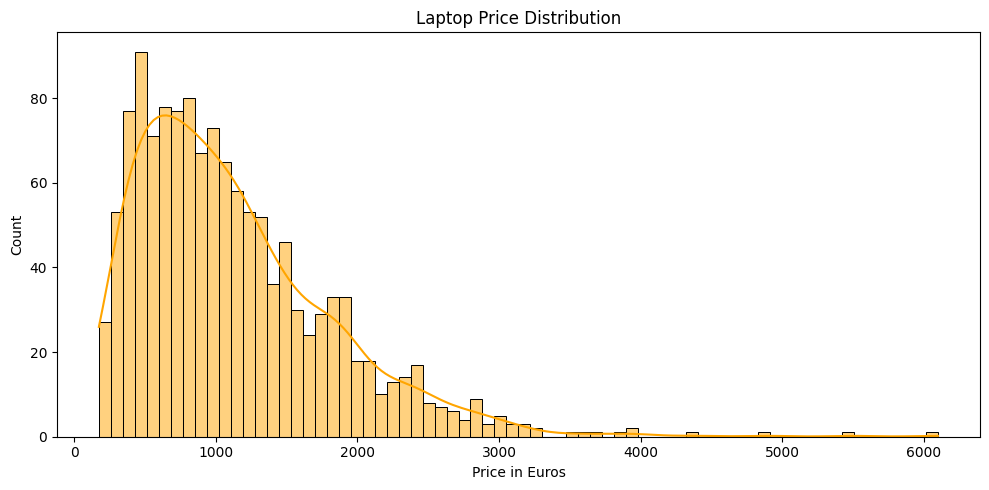

In [479]:
plt.figure(figsize=(10,5))
sns.histplot(df["Price_euros"], bins=70, kde=True, color="orange") #bins for granularity/detail, kde=True to show density curve
plt.title("Laptop Price Distribution")
plt.xlabel("Price in Euros")
plt.tight_layout()
plt.show()

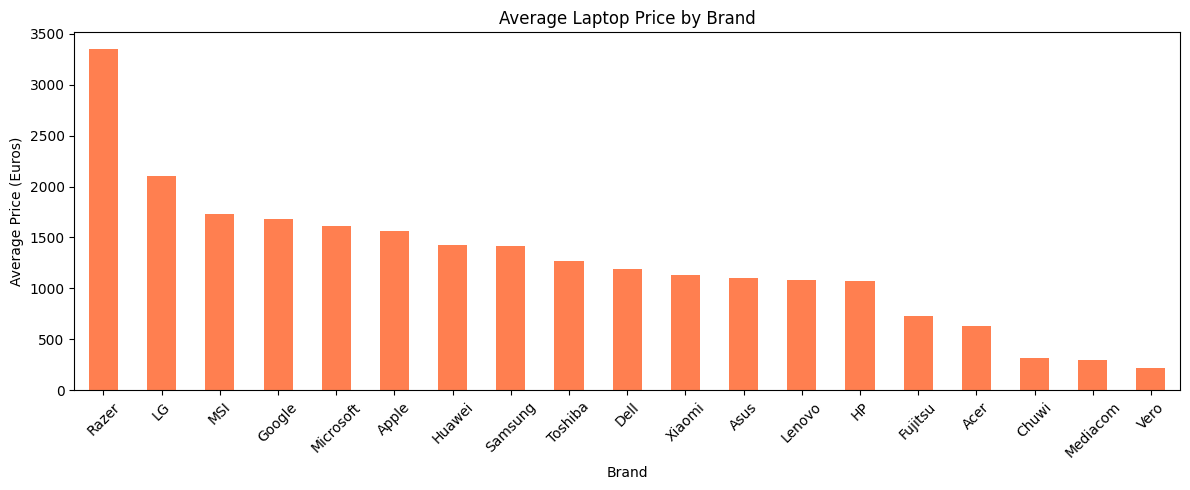

In [480]:
avg_price = df.groupby("Company")["Price_euros"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
avg_price.plot(kind="bar", color="coral")
plt.title("Average Laptop Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price (Euros)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [481]:
df["Ram"] = df["Ram"].str.replace("GB","").astype(int) #Remove "GB" and convert to integer

df["Weight"] = df["Weight"].str.replace("kg","").astype(float) #Remove "kg" and convert to float because has decimal values

print(df[["Ram", "Weight"]].head())
print(df[["Ram", "Weight"]].dtypes)

   Ram  Weight
0    8    1.37
1    8    1.34
2    8    1.86
3   16    1.83
4    8    1.37
Ram         int64
Weight    float64
dtype: object


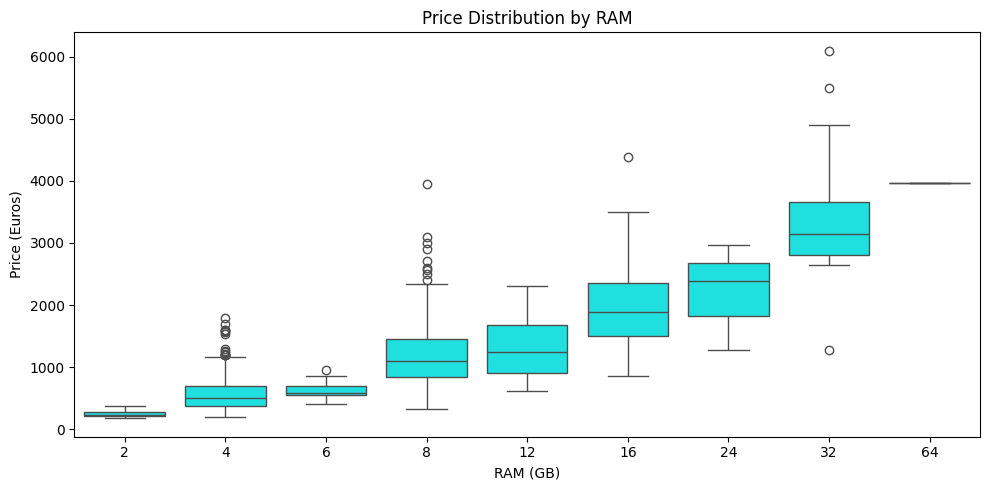

In [482]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Ram", y="Price_euros", data=df, color="cyan") #data=df to specify the DataFrame
plt.title("Price Distribution by RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (Euros)")
plt.tight_layout()
plt.show()

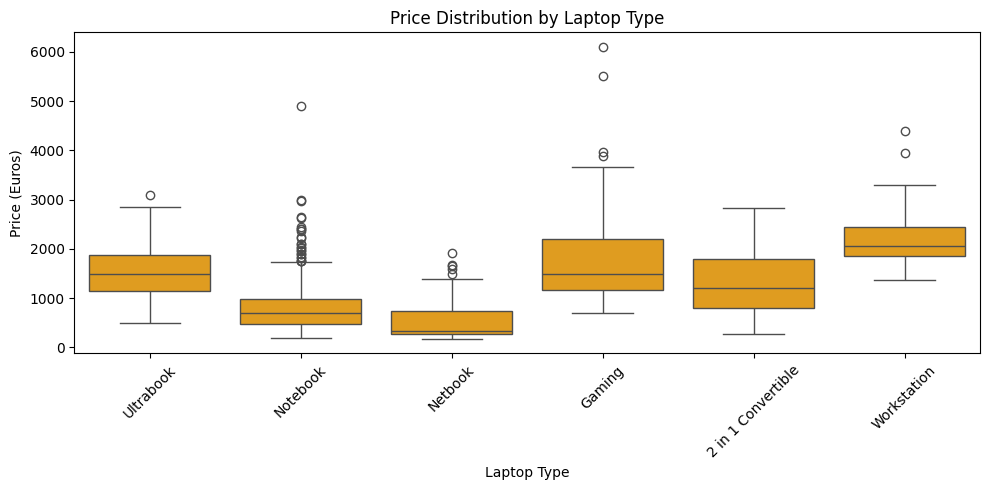

In [483]:
plt.figure(figsize=(10,5))
sns.boxplot(x="TypeName", y="Price_euros", data=df, color="orange")
plt.title("Price Distribution by Laptop Type")
plt.xlabel("Laptop Type")
plt.ylabel("Price (Euros)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

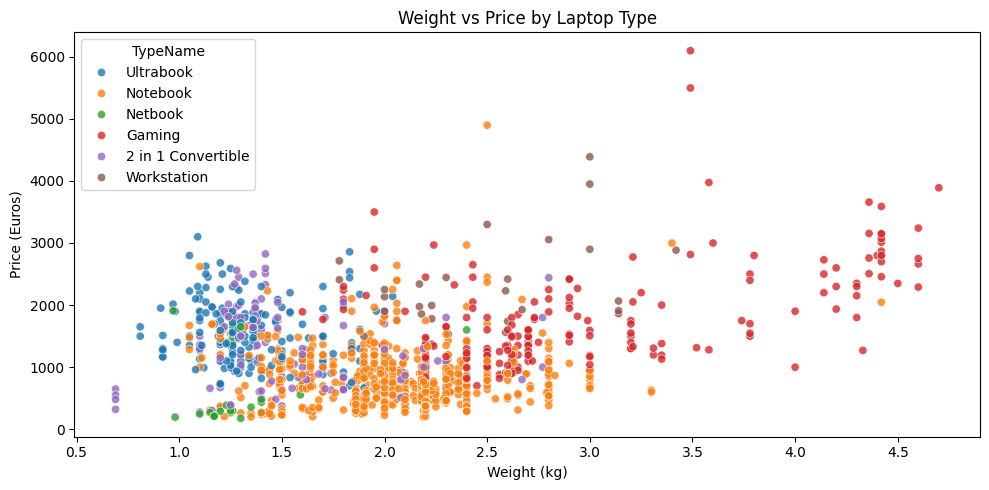

In [484]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Weight", y="Price_euros", hue="TypeName", data=df, alpha=0.8) #alpha for transparency
plt.title("Weight vs Price by Laptop Type")
plt.xlabel("Weight (kg)")
plt.ylabel("Price (Euros)")
plt.tight_layout()
plt.show()

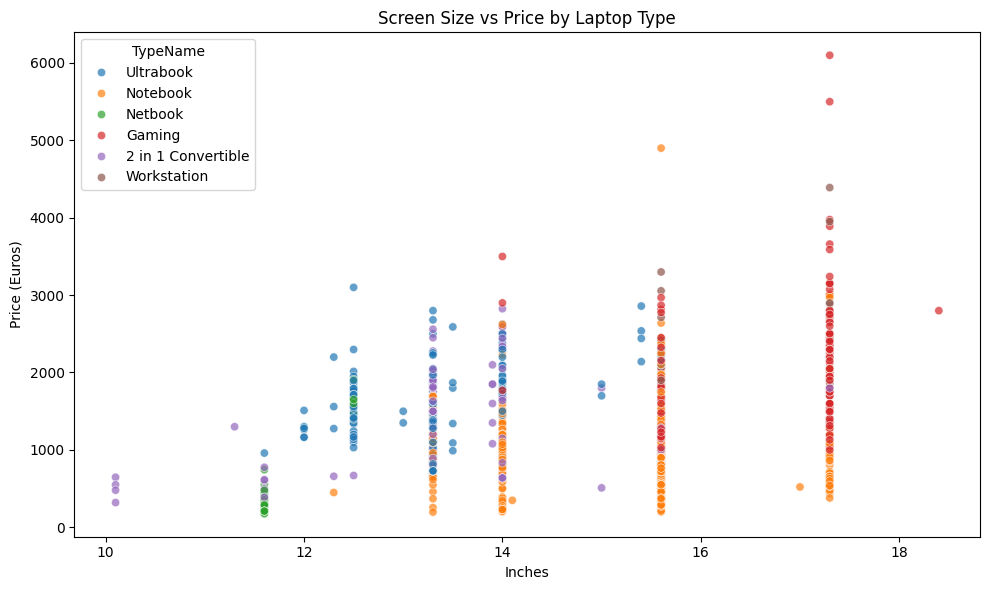

In [485]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Inches", y="Price_euros", hue="TypeName", data=df, alpha=0.7)
plt.title("Screen Size vs Price by Laptop Type")
plt.xlabel("Inches")
plt.ylabel("Price (Euros)")
plt.tight_layout()
plt.show()

In [486]:
big_screen = df[df["Inches"] > 18]
print(big_screen[["Company", "TypeName", "Inches", "Price_euros"]])

    Company TypeName  Inches  Price_euros
177     MSI   Gaming    18.4       2799.0


In [487]:
summary = df.groupby("Company").agg( #aggregate multiple statistics
    avg_price=("Price_euros", "mean"),
    avg_ram=("Ram", "mean"),
    avg_weight=("Weight", "mean"),
    count=("Product", "count")
).round(2).sort_values("avg_price", ascending=False)

print(summary)

           avg_price  avg_ram  avg_weight  count
Company                                         
Razer        3346.14    19.43        2.20      7
LG           2099.00    10.67        1.05      3
MSI          1728.91    13.04        2.66     54
Google       1677.67    10.67        1.10      3
Microsoft    1612.31     8.00        1.25      6
Apple        1564.20     9.33        1.32     21
Huawei       1424.00     8.00        1.05      2
Samsung      1413.44    10.67        1.32      9
Toshiba      1267.81     8.67        1.64     48
Dell         1186.07     9.15        2.15    297
Xiaomi       1133.46    10.00        1.62      4
Asus         1104.17     9.59        2.22    158
Lenovo       1086.38     8.04        2.00    297
HP           1067.77     6.91        1.91    274
Fujitsu       729.00     6.67        2.23      3
Acer          626.78     5.98        2.17    103
Chuwi         314.30     4.67        1.73      3
Mediacom      295.00     3.71        1.34      7
Vero          217.42

# Now onto the more advanced sections

## CPU & GPU Analysis
Extracting CPU Brand, CPU Tier, and GPU Brand from raw text columns

In [488]:
def get_cpu_brand(text): #Extract CPU Brand from text
    if "Intel" in str(text): return "Intel"
    elif "AMD" in str(text): return "AMD"
    else: return "Other"

def get_cpu_tier(text): #Extract CPU Tier from text
    text = str(text)
    for tier in ["Core i9", "Core i7", "Core i5", "Core i3"]:
        if tier in text: return tier
    if "AMD" in text: return "AMD"
    return "Other"

def get_gpu_brand(text): #Extract GPU Brand from text
    text = str(text)
    if "Nvidia" in text: return "Nvidia"
    elif "AMD" in text: return "AMD"
    elif "Intel" in text: return "Intel"
    else: return "Other"

df["cpu_brand"] = df["Cpu"].apply(get_cpu_brand)
df["cpu_tier"] = df["Cpu"].apply(get_cpu_tier)
df["gpu_brand"] = df["Gpu"].apply(get_gpu_brand)

print(df["cpu_brand"].value_counts(), "\n")
print(df["cpu_tier"].value_counts(), "\n")
print(df["gpu_brand"].value_counts())

cpu_brand
Intel    1240
AMD        62
Other       1
Name: count, dtype: int64 

cpu_tier
Core i7    527
Core i5    423
Other      155
Core i3    136
AMD         62
Name: count, dtype: int64 

gpu_brand
Intel     722
Nvidia    400
AMD       180
Other       1
Name: count, dtype: int64


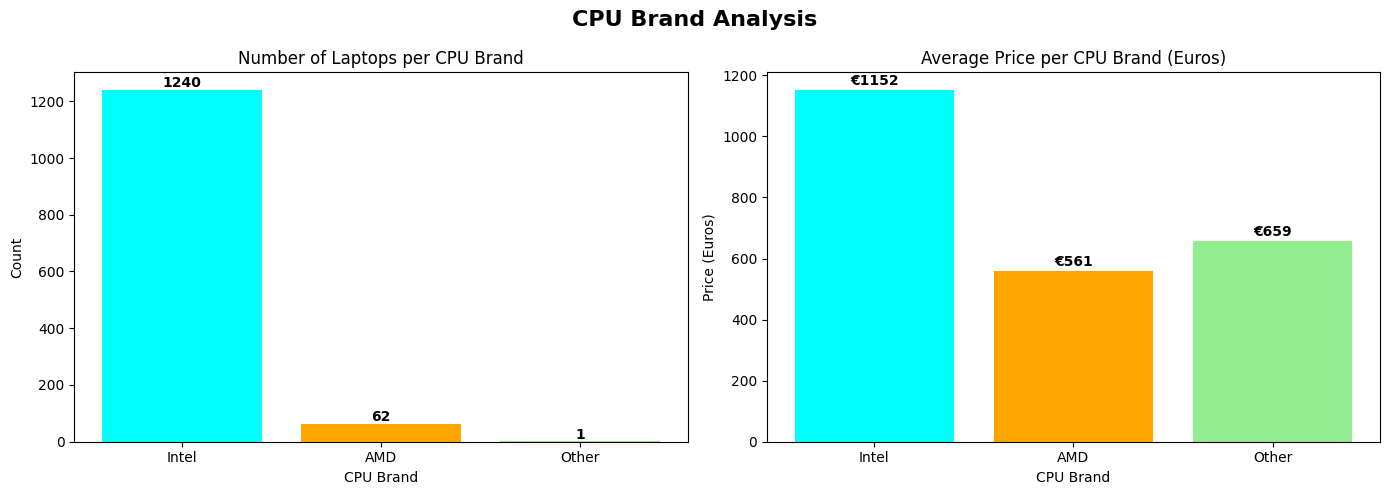

In [489]:
fig, axes = plt.subplots(1, 2, figsize=(14,5)) #1,2 for 1 row, 2 columns of subplots
fig.suptitle("CPU Brand Analysis", fontsize=16, fontweight="bold") #suptitle for overall title

cpu_counts = df["cpu_brand"].value_counts()
colors = ["cyan", "orange", "lightgreen"]

axes[0].bar(cpu_counts.index, cpu_counts.values, color=colors) #first is x values, second is y values(height of bars), third is color for all bars
axes[0].set_title("Number of Laptops per CPU Brand")
axes[0].set_xlabel("CPU Brand")
axes[0].set_ylabel("Count")
for i, v in enumerate(cpu_counts.values): #enumerate to loop through values and add text labels
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold") #v+5 to position text above the bar at 5 units high, ha means horizontal alignment
    
avg_cpu = df.groupby("cpu_brand")["Price_euros"].mean().reindex(cpu_counts.index) #reindex to match the order of cpu_counts
axes[1].bar(avg_cpu.index, avg_cpu.values, color=colors)
axes[1].set_title("Average Price per CPU Brand (Euros)")
axes[1].set_xlabel("CPU Brand")
axes[1].set_ylabel("Price (Euros)")
for i, v in enumerate(avg_cpu.values):
    axes[1].text(i, v + 15, f"€{v:.0f}", ha="center", fontweight="bold") #v:.0f to format as integer, if want decimal can change 0 to 1 or 2

plt.tight_layout()
plt.show()

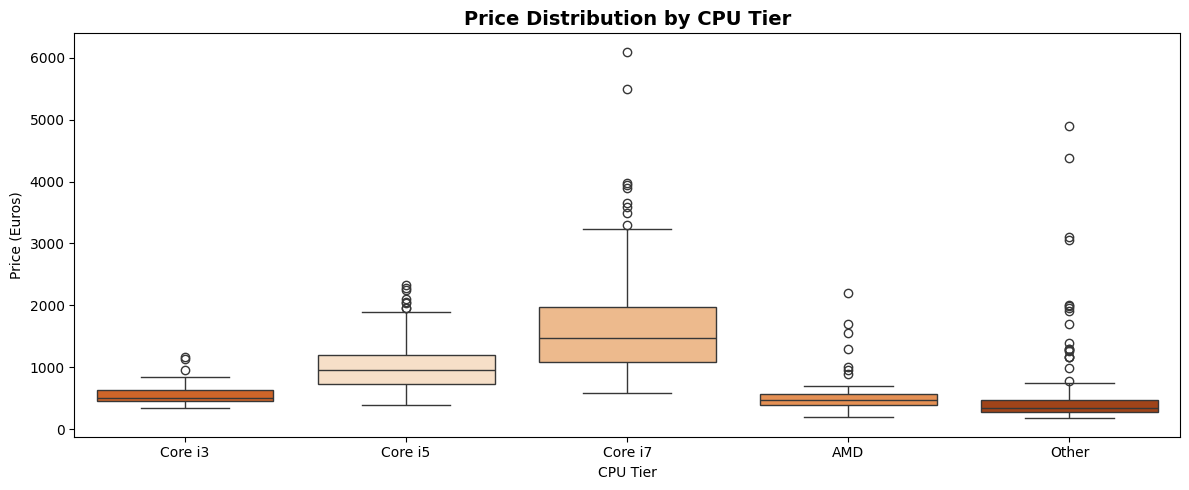

In [490]:
tier_order = ["Core i3", "Core i5", "Core i7", "Core i9", "AMD", "Other"] #Define custom order for CPU tiers
tier_order = [t for t in tier_order if t in df["cpu_tier"].unique()] #Filter to only tiers that exist in data

plt.figure(figsize=(12,5))
sns.boxplot(data=df, x="cpu_tier", y="Price_euros", order=tier_order, palette="Oranges", hue="cpu_tier")
plt.title("Price Distribution by CPU Tier", fontweight="bold", fontsize=14)
plt.xlabel("CPU Tier")
plt.ylabel("Price (Euros)")
plt.tight_layout()
plt.show()

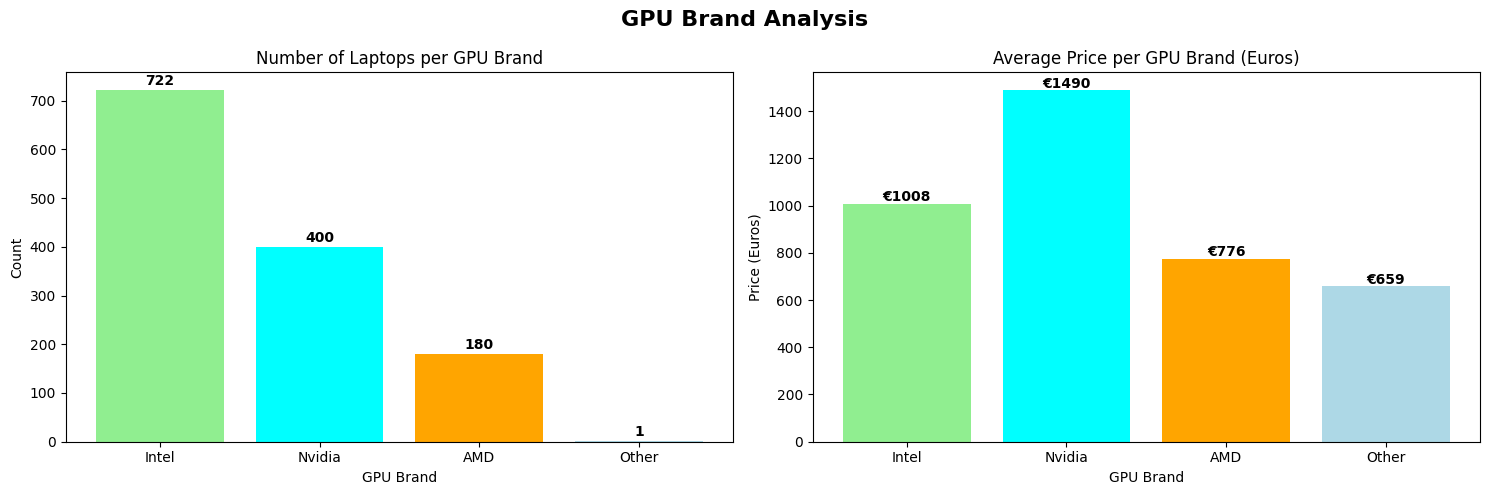

In [491]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle("GPU Brand Analysis", fontsize=16, fontweight="bold")

gpu_counts = df["gpu_brand"].value_counts()
colors = ["lightgreen", "cyan", "orange", "lightblue"][:len(gpu_counts)] #4 slots because 4 GPU brands, len to ensure the colors match the number of GPU brands

axes[0].bar(gpu_counts.index, gpu_counts.values, color=colors)
axes[0].set_title("Number of Laptops per GPU Brand")
axes[0].set_xlabel("GPU Brand")
axes[0].set_ylabel("Count")
for i, v in enumerate(gpu_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold") #Can add fontstyle (italic, normal, oblique) too

avg_gpu = df.groupby("gpu_brand")["Price_euros"].mean().reindex(gpu_counts.index)
axes[1].bar(avg_gpu.index, avg_gpu.values, color=colors)
axes[1].set_title("Average Price per GPU Brand (Euros)")
axes[1].set_xlabel("GPU Brand")
axes[1].set_ylabel("Price (Euros)")
for i, v in enumerate(avg_gpu.values):
    axes[1].text(i, v + 10, f"€{v:.0f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

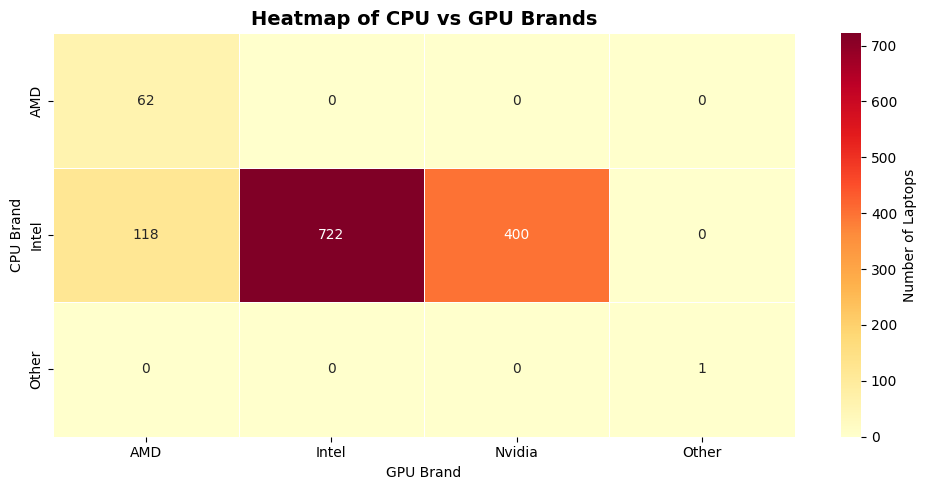

In [492]:
#Heatmap CPU x GPU

hm = df.groupby(["cpu_brand", "gpu_brand"]).size().unstack(fill_value=0) #size to count occurrences, unstack to pivot gpu_brand to columns,fill value for NaN
#in groupby, first column is y (rows), second column is x (columns)

plt.figure(figsize=(10,5))
sns.heatmap(hm, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "Number of Laptops"}) #YlOrRd is Yellow-Orange-Red
#annot=True to show counts in each cell, fmt="d" to format as integer, cmap for color scheme,cbar_kws to label the colorbar
plt.title("Heatmap of CPU vs GPU Brands", fontweight="bold", fontsize=14)
plt.xlabel("GPU Brand")
plt.ylabel("CPU Brand")
plt.tight_layout()
plt.show()

# Correlation Heatmap
Which numeric features are most related to price?

In [493]:
numeric_df = df[["Inches", "Ram", "Weight", "Price_euros"]].copy() #copy to avoid settingwithcopy warning

print(numeric_df.describe())

            Inches          Ram       Weight  Price_euros
count  1303.000000  1303.000000  1303.000000  1303.000000
mean     15.017191     8.382195     2.038734  1123.686992
std       1.426304     5.084665     0.665475   699.009043
min      10.100000     2.000000     0.690000   174.000000
25%      14.000000     4.000000     1.500000   599.000000
50%      15.600000     8.000000     2.040000   977.000000
75%      15.600000     8.000000     2.300000  1487.880000
max      18.400000    64.000000     4.700000  6099.000000


In [494]:
corr = numeric_df.corr()
print(corr)

               Inches       Ram    Weight  Price_euros
Inches       1.000000  0.237993  0.827631     0.068197
Ram          0.237993  1.000000  0.383874     0.743007
Weight       0.827631  0.383874  1.000000     0.210370
Price_euros  0.068197  0.743007  0.210370     1.000000


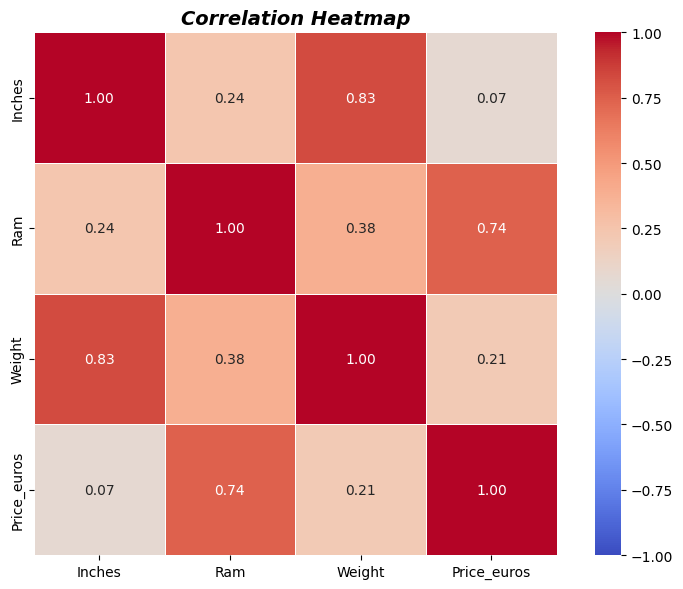

In [495]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5, square=True) #vmin and vmax set color scale from full -1 to 1
plt.title("Correlation Heatmap", fontweight="bold", fontstyle="italic", fontsize=14)
plt.tight_layout()
plt.show()

# Interactive Plotly Charts
Unlike Matplotlib, Plotly charts let us zoom, hover, and filter live.

In [496]:
import plotly.express as px

avg_brand = (df.groupby("Company")["Price_euros"].mean().sort_values(ascending=False).reset_index())
avg_brand.columns = ["Company", "Avg_Price"]
avg_brand["Avg_Price"] = avg_brand["Avg_Price"].round(0)

fig = px.bar(avg_brand, x="Company", y="Avg_Price", title="Average Laptop Price by Brand", color="Avg_Price",
             color_continuous_scale="Blues", text="Avg_Price", labels={"Avg_Price": "Avg Price (Euros)", "Company" : "Brand"})
# color based on avg price, text to show avg price on top of bars, labels to rename axis

fig.update_traces(texttemplate="€%{text:.0f}", textposition="outside") #traces to customize text labels, textposition outside is for text above bars,%{text:,.0f} is to insert the value and add .0f 
fig.update_layout(height=500, showlegend=False) #layout to adjust figure height and hide legend
fig.show()

In [497]:
fig2 = px.scatter(df, x="Ram", y="Price_euros", color="cpu_tier", hover_data=["Company", "TypeName", "Gpu"],
                  title="RAM vs Price (colored by CPU Tier)", labels={"Ram": "RAM (GB)", "Price_euros": "Price (Euros)", "cpu_tier": "CPU Tier"},
                  opacity=0.8, category_orders={"cpu_tier": ["Core i3", "Core i5", "Core i7", "Core i9", "AMD", "Other"]})
#hover data will show the 3 additional infos
fig2.update_layout(height=500)
fig2.show()

In [498]:
fig3 =px.box(df, x="TypeName", y="Price_euros", color="TypeName", title="Price Distribution by Laptop Type",
             labels={"TypeName": "Type Name", "Price_euros": "Price (Euros)"}, points="outliers")
#points to show only outliers, can change to "all" to show all points or "suspectedoutliers" for only suspected outliers
fig3.update_layout(height=500, showlegend=False)
fig3.show()

# Price Predictor (Linear Regression)
Predicting laptop price from RAM, Weight, CPU tier, GPU Brand, and Laptop Type. (This is my first ML model!)

In [499]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

print("Scikit-learn ready!")

Scikit-learn ready!


In [500]:
#ML models only understand numbers, so we need to convert categorical variables to numeric (integer) using LabelEncoder

le = LabelEncoder()
df["cpu_tier_enc"] = le.fit_transform(df["cpu_tier"]) #le.fit_transform will asign an integer to each unique category in "cpu_tier" and make a new column
df["gpu_brand_enc"] = le.fit_transform(df["gpu_brand"])
df["type_enc"] = le.fit_transform(df["TypeName"])

print(df[["cpu_tier", "cpu_tier_enc"]].drop_duplicates().sort_values("cpu_tier_enc")) #drop_duplicates to show only unique pairs
print(df[["gpu_brand", "gpu_brand_enc"]].drop_duplicates().sort_values("gpu_brand_enc"))
print(df[["TypeName", "type_enc"]].drop_duplicates().sort_values("type_enc"))

   cpu_tier  cpu_tier_enc
5       AMD             0
11  Core i3             1
0   Core i5             2
3   Core i7             3
14    Other             4
     gpu_brand  gpu_brand_enc
3          AMD              0
0        Intel              1
8       Nvidia              2
1191     Other              3
               TypeName  type_enc
23   2 in 1 Convertible         0
21               Gaming         1
20              Netbook         2
2              Notebook         3
0             Ultrabook         4
204         Workstation         5


In [501]:
#x is features (inputs the model learns from), y is target (what we want to predict)
x = df[["Ram", "Weight", "Inches", "cpu_tier_enc", "gpu_brand_enc", "type_enc"]]
y = df["Price_euros"]

print("x shape:", x.shape)
print("y shape:", y.shape)
print()
print(x.head(3))
print()
print(y.head(3))

x shape: (1303, 6)
y shape: (1303,)

   Ram  Weight  Inches  cpu_tier_enc  gpu_brand_enc  type_enc
0    8    1.37    13.3             2              1         4
1    8    1.34    13.3             2              1         4
2    8    1.86    15.6             2              1         3

0    1339.69
1     898.94
2     575.00
Name: Price_euros, dtype: float64


In [502]:
#test_size = 0.2 means 20% goes to testing, 80% goes to training
#random_state=42 means the split is the same everytime you run it
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 1042
Testing samples: 261


In [503]:
model = LinearRegression()
model.fit(x_train, y_train) #This is where the learning starts, "fit" the x and y training data to the model

print("Model trained successfully!")
print()
feature_names = x.columns.tolist() #get the feature names from x columns and convert to list
for name, coef in zip(feature_names, model.coef_): #zip to loop through feature names and coefficients together, "_" is for the attribute that only exists after training the model
    print(f"{name:20s} → €{coef:+.2f} per unit") #"20" is to reserve 20 characters of width for spacing, "+" means always show the sign of the coef

Model trained successfully!

Ram                  → €+99.47 per unit
Weight               → €+55.11 per unit
Inches               → €-86.46 per unit
cpu_tier_enc         → €+4.81 per unit
gpu_brand_enc        → €+161.00 per unit
type_enc             → €+44.54 per unit


In [504]:
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred) #MAE is the average absolute difference between y_test and y_pred, lower is better
r2 = r2_score(y_test, y_pred) #R2 is the proportion of variance in y_test that is explained by y_pred, higher is better (max 1.0)

print(f"MAE: €{mae:.2f}")
print(f"R2 score: {r2:.2f}")
print()
print("What these mean:")
print(f" → On average, predictions are off by €{mae:.2f} from the actual price.")
print(f" → The model explains {r2*100:.0f}% of the variation in price")



MAE: €331.86
R2 score: 0.58

What these mean:
 → On average, predictions are off by €331.86 from the actual price.
 → The model explains 58% of the variation in price


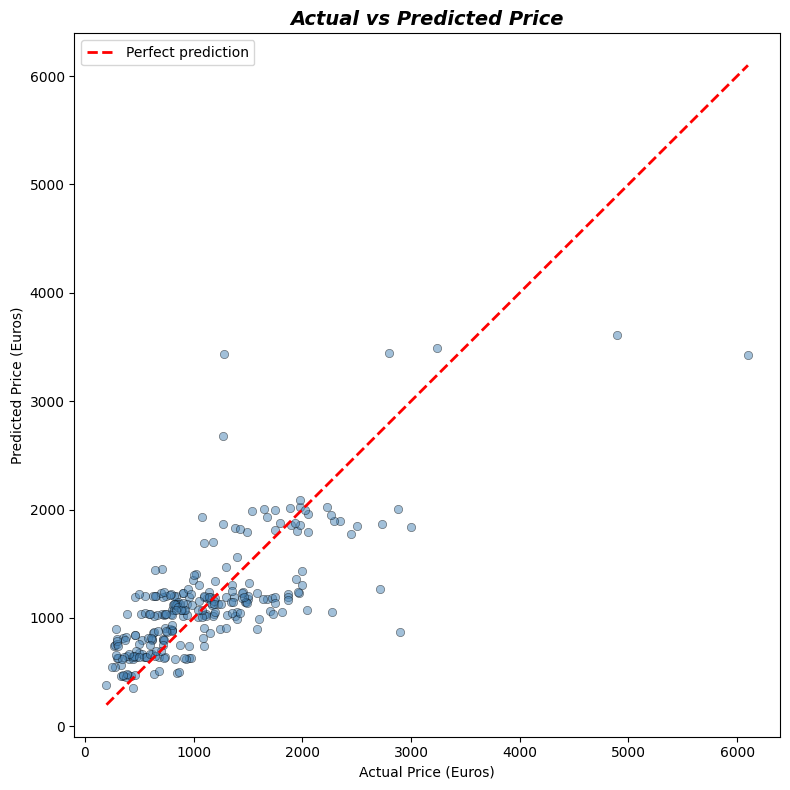

In [505]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue", edgecolors="black", linewidths=0.5) #edgecolors are for the dots, alpha for transparency
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linewidth=2, linestyle="--", label="Perfect prediction")
#plt.plot is to draw the perfect prediction line (R2 = 1) , linewidth for thickness of line, linestyle for dashed line
#line styles: "-" solid, "--" dashed, ":" dotted, "-." dash-dot
plt.title("Actual vs Predicted Price", fontweight="bold", fontstyle="italic", fontsize=14)
plt.xlabel("Actual Price (Euros)")
plt.ylabel("Predicted Price (Euros)")
plt.legend()
plt.tight_layout()
plt.show()

In [506]:
#Predict the price of a customized laptop
#Can change these values and re-run to see different predictions

custom = pd.DataFrame([{
    "Ram" : 16,
    "Weight" : 2.0,
    "Inches" : 15.6,
    "cpu_tier_enc" : 3,
    "gpu_brand_enc": 2,
    "type_enc": 5
}])

predicted_price = model.predict(custom)[0] #get the model to predict customized laptop price, [0] to get the single value from the array
print(f"Predicted Price: €{predicted_price:.2f}")

Predicted Price: €2078.47


# Feature Engineering
Extracting more useful features from Memory, ScreenResolution, and OpSys

In [507]:
print(df["Memory"].value_counts().head(10))
print()
print(df["ScreenResolution"].value_counts().head(10))
print()
print(df["OpSys"].value_counts().head(10))

Memory
256GB SSD               412
1TB HDD                 223
500GB HDD               132
512GB SSD               118
128GB SSD +  1TB HDD     94
128GB SSD                76
256GB SSD +  1TB HDD     73
32GB Flash Storage       38
2TB HDD                  16
64GB Flash Storage       15
Name: count, dtype: int64

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
Name: count, dtype: int64

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
m

In [508]:
def has_ssd(text):
    return 1 if "SSD" in str(text) else 0

def has_hdd(text):
    return 1 if "HDD" in str(text) else 0

def get_storage_gb(text):
    text = str(text)
    import re #Regular expressions
    match = re.search(r"(\d+)(GB|TB)", text) #Search for a number followed by GB or TB
    if match:
        value = int(match.group(1)) #Get the number part only
        unit = match.group(2) #Get the unit part (GB or TB)
        return value * 1000 if unit == "TB" else value #Convert TB to GB
    return 0 #if no match found
df["has_ssd"] = df["Memory"].apply(has_ssd)
df["has_hdd"] = df["Memory"].apply(has_hdd)
df["storage_gb"] = df["Memory"].apply(get_storage_gb)

print(df[["Memory", "has_ssd", "has_hdd", "storage_gb"]].head(10))

                Memory  has_ssd  has_hdd  storage_gb
0            128GB SSD        1        0         128
1  128GB Flash Storage        0        0         128
2            256GB SSD        1        0         256
3            512GB SSD        1        0         512
4            256GB SSD        1        0         256
5            500GB HDD        0        1         500
6  256GB Flash Storage        0        0         256
7  256GB Flash Storage        0        0         256
8            512GB SSD        1        0         512
9            256GB SSD        1        0         256


In [509]:
import re

def get_resolution(text, dimension):
    match = re.search(r"(\d{3,4})x(\d{3,4})", str(text)) #3,4 digits
    if match:
        return int(match.group(1)) if dimension == "width" else int(match.group(2))
    return 0

df["res_width"] = df["ScreenResolution"].apply(lambda x: get_resolution(x, "width")) #lambda to apply the function to each value to the column
df["res_height"] = df["ScreenResolution"].apply(lambda x: get_resolution(x, "height"))
df["total_pixels"] = df["res_width"] * df["res_height"]

print(df[["ScreenResolution", "res_width", "res_height", "total_pixels"]].head(10))

                     ScreenResolution  res_width  res_height  total_pixels
0  IPS Panel Retina Display 2560x1600       2560        1600       4096000
1                            1440x900       1440         900       1296000
2                   Full HD 1920x1080       1920        1080       2073600
3  IPS Panel Retina Display 2880x1800       2880        1800       5184000
4  IPS Panel Retina Display 2560x1600       2560        1600       4096000
5                            1366x768       1366         768       1049088
6  IPS Panel Retina Display 2880x1800       2880        1800       5184000
7                            1440x900       1440         900       1296000
8                   Full HD 1920x1080       1920        1080       2073600
9         IPS Panel Full HD 1920x1080       1920        1080       2073600


In [510]:
def simplify_os(text):
    text = str(text).lower() #convert to lowercase for easier matching
    if "windows" in text: return "Windows"
    elif "mac" in text: return "macOS"
    elif "linux" in text: return "Linux"
    elif "chrome" in text: return "Chrome OS"
    else: return "Other"

df["os_simple"] = df["OpSys"].apply(simplify_os)
le_os = LabelEncoder()
df["os_enc"] = le_os.fit_transform(df["os_simple"]) #to create a new encoded column for the simplified OS

print(df[["OpSys", "os_simple", "os_enc"]].head(10))

        OpSys os_simple  os_enc
0       macOS     macOS       4
1       macOS     macOS       4
2       No OS     Other       2
3       macOS     macOS       4
4       macOS     macOS       4
5  Windows 10   Windows       3
6    Mac OS X     macOS       4
7       macOS     macOS       4
8  Windows 10   Windows       3
9  Windows 10   Windows       3


In [511]:
x2 = df[["Ram", "Weight", "Inches", "cpu_tier_enc", "gpu_brand_enc", "type_enc", "has_ssd", "has_hdd", "storage_gb", "total_pixels", "os_enc"]]
y = df["Price_euros"]

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y, test_size=0.2, random_state=69)

model2 = LinearRegression()
model2.fit(x2_train, y2_train)
y2_pred = model2.predict(x2_test)

mae2 = mean_absolute_error(y2_test, y2_pred)
r2_2 = r2_score(y2_test, y2_pred)

print("=== Linear Regression Round 2 ===")
print(f"MAE : €{mae2:.2f}, was €{mae:.2f} before")
print(f"R2 : {r2_2:.2f}, was {r2:.2f} before")
print()

for name, coef in zip(x2.columns, model2.coef_):
    print(f"{name:20s} → €{coef:+.2f}")

=== Linear Regression Round 2 ===
MAE : €267.76, was €331.86 before
R2 : 0.66, was 0.58 before

Ram                  → €+76.69
Weight               → €+130.53
Inches               → €-69.97
cpu_tier_enc         → €+42.76
gpu_brand_enc        → €+85.70
type_enc             → €+43.56
has_ssd              → €+309.31
has_hdd              → €-21.07
storage_gb           → €+0.10
total_pixels         → €+0.00
os_enc               → €+118.64


# Random Forest Model

In [512]:
from sklearn.ensemble import RandomForestRegressor 
#RandomForest is a more complex model that can capture non-linear relationships and interactions between features

rf_model = RandomForestRegressor(n_estimators=1000, random_state=102)
#n_estimators is the number of trees in the forest, more is better but take longer to train
rf_model.fit(x2_train, y2_train)
rf_pred = rf_model.predict(x2_test)

mae_rf = mean_absolute_error(y2_test, rf_pred)
r2_rf = r2_score(y2_test, rf_pred)

print("=== Random Forest Regression ===")
print(f"MAE: €{mae_rf:.2f}, was €{mae2:.2f} with linear regression")
print(f"R2: {r2_rf:.2f}, was {r2_2:.2f} with linear regression")

=== Random Forest Regression ===
MAE: €203.62, was €267.76 with linear regression
R2: 0.72, was 0.66 with linear regression


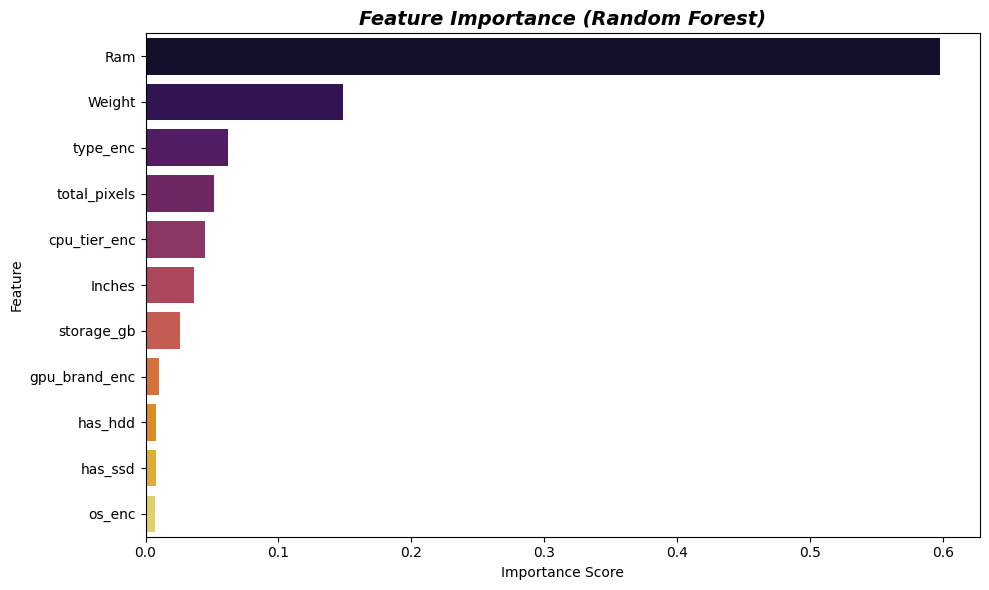

In [513]:
importances = pd.Series(rf_model.feature_importances_, index=x2.columns)
#feature_importances_ is an attribute of the trained random forest model that gives the importance score for each feature, higher means more important
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index, palette="inferno", hue=importances.index) #or magma, plasma, viridis, cividis
plt.title("Feature Importance (Random Forest)", fontweight="bold", fontstyle="italic", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

               Model        MAE       R2
Linear Regression v1 331.862636 0.576233
Linear Regression v2 267.763911 0.655649
       Random Forest 203.615417 0.716441


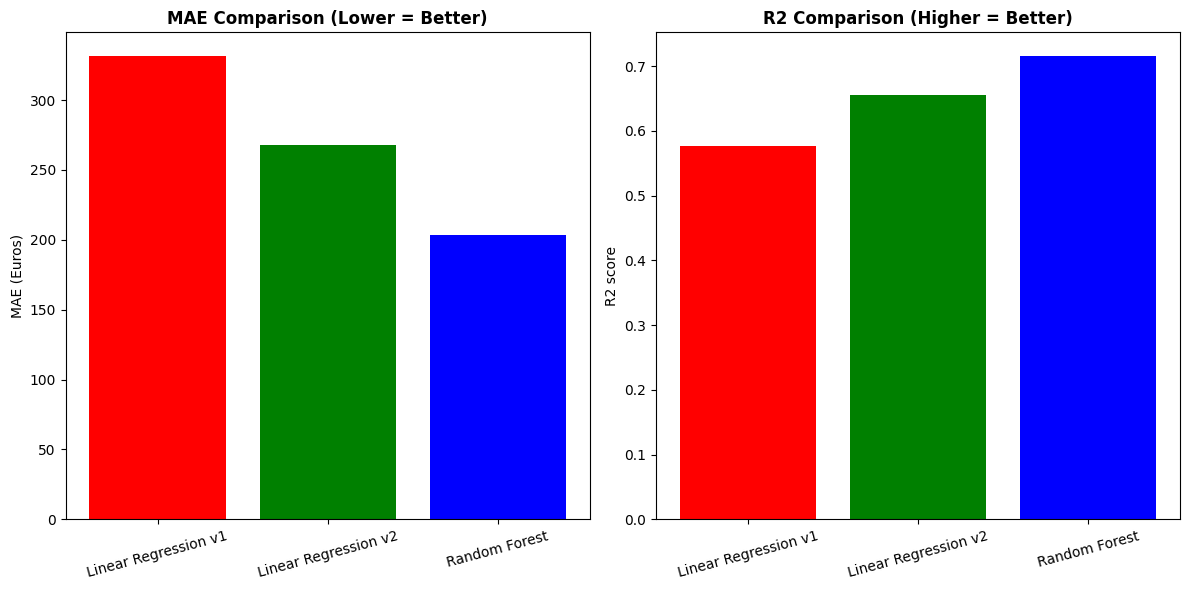

In [514]:
results = pd.DataFrame({
    "Model": ["Linear Regression v1", "Linear Regression v2", "Random Forest"],
    "MAE": [mae, mae2, mae_rf],
    "R2": [r2, r2_2, r2_rf]
})

print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].bar(results["Model"], results["MAE"], color=["red","green", "blue"])
axes[0].set_title("MAE Comparison (Lower = Better)", fontweight="bold")
axes[0].set_ylabel("MAE (Euros)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(results["Model"], results["R2"], color=["red", "green", "blue"])
axes[1].set_title("R2 Comparison (Higher = Better)", fontweight="bold")
axes[1].set_ylabel("R2 score")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# And that is it for this laptop analysis!